# Milestone 3: Route, Cancellation, and Seasonal Insights

**1. Objective of Milestone 3**

The objective of Milestone 3 is to analyze airline operations at the route level, airport level, and seasonal level. This milestone focuses on identifying the busiest routes, delay-prone airports, cancellation trends, and seasonal patterns affecting airline performance.

This analysis helps in understanding:

*   Which routes have the highest traffic
*   Which airports experience the most delays
*   When cancellations happen the most
*   What are the main reasons for cancellations
*   How seasons affect delays and cancellations

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/CA-2/airline_Cleaned_data.csv")
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,DEP_HOUR,ARR_HOUR,ROUTE,IS_DELAYED
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,1065.0,0.0,0.0,0.0,0.0,0.0,11,15,FLL-EWR,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,1399.0,0.0,0.0,0.0,0.0,0.0,21,23,MSP-SEA,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,680.0,0.0,0.0,0.0,0.0,0.0,9,12,DEN-MSP,0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,1589.0,0.0,0.0,24.0,0.0,0.0,16,18,MSP-SFO,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,985.0,0.0,0.0,0.0,0.0,0.0,18,20,MCO-DFW,0


# Part 1: Route and Airport-Level Analysis

**1..Top Origin–Destination Routes Analysis**


In this analysis, we identify the top 10 busiest routes based on the number of flights between origin and destination airports.

Why We Are Doing This

This helps us understand:

*   High demand routes
*   Congested routes
*   Routes where delays are more likely due to heavy traffic
*   Chart Used
--- Bar Chart: Top 10 Busiest Routes

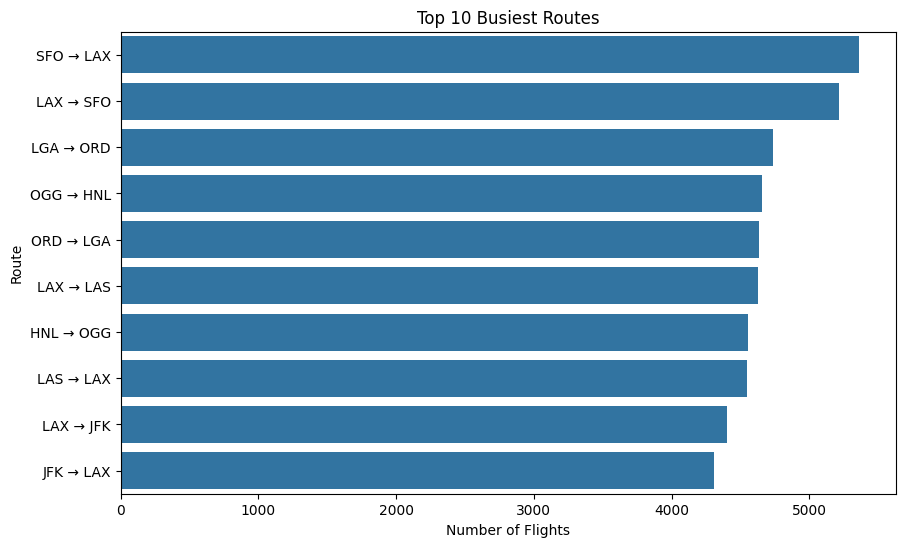

In [5]:
top_routes = df.groupby(['ORIGIN', 'DEST']).size().reset_index(name='COUNT')
top_routes = top_routes.sort_values(by='COUNT', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='COUNT', y=top_routes['ORIGIN'] + " → " + top_routes['DEST'], data=top_routes)
plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

   **Insight:**
   * The chart shows the top 10 busiest flight routes based on the number of flights.
   * Routes such as SFO → LAX and LAX → SFO have the highest number of flights, indicating very high passenger traffic between these cities.
   * Most of the busiest routes are between major airports, which shows that large cities have higher flight demand.
   * High traffic routes may experience more delays due to congestion and heavy air traffic.
   * Airlines should focus on improving scheduling and delay management on these busy routes.
   * These routes are important for airline revenue because they carry a large number of passengers.

**2..Busiest Airports Analysis**


We identify the airports with the highest number of departing flights.

Why We Are Doing This

This helps to:

*   Identify busiest airports
*   Understand airport traffic load
*   Analyze whether busy airports have more delays
*   Chart Used--
Bar Chart: Top 10 Busiest Airports

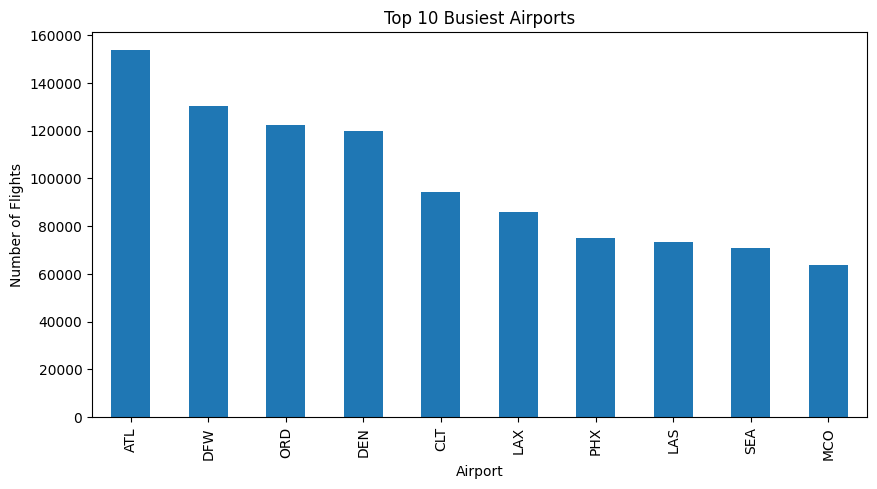

In [6]:
busiest_airports = df['ORIGIN'].value_counts().head(10)

busiest_airports.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.show()

   **Insight:**
   * The chart shows the top 10 busiest airports based on the number of departing flights.
   * ATL (Atlanta) has the highest number of flights, making it the busiest airport in the dataset.
   * Other major airports like DFW, ORD, and DEN also handle a large number of flights.
   * These airports act as major hubs for airline operations and connect many routes.
   * Busiest airports may experience more delays due to heavy traffic and congestion.
   * Airlines and airport authorities should improve traffic management and scheduling at these airports to reduce delays.

**3. Average Delay by Airport (Heatmap)**


We calculate the average arrival delay for each airport and visualize it using a heatmap.

Why We Are Doing This

This helps to:

*   Identify delay-prone airports
*   Understand airport performance
*   Help airlines improve scheduling at those airports
*   Chart Used:
Heatmap

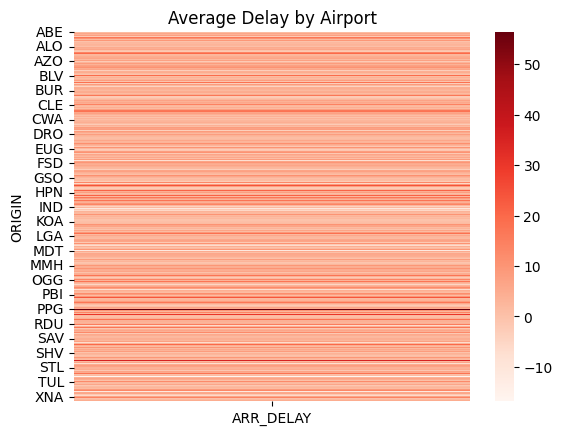

In [7]:
delay_airport = df.groupby('ORIGIN')['ARR_DELAY'].mean().reset_index()
delay_airport = delay_airport.pivot_table(values='ARR_DELAY', index='ORIGIN')

sns.heatmap(delay_airport, cmap='Reds')
plt.title("Average Delay by Airport")
plt.show()

  **Insight:**
   * The heatmap shows the average arrival delay for each airport.
   * Darker colors indicate higher average delays, while lighter colors indicate lower delays.
   * Some airports show higher average delays, which may be due to heavy traffic, weather conditions, or operational issues.
   * Airports with consistently high delays may require better scheduling and traffic management.
   * This analysis helps identify delay-prone airports so airlines can take corrective actions.
   * Improving operations at high-delay airports can help reduce overall flight delays.

**4. Average Delay by Route**

We calculate the average delay for each route and find the routes with the highest delays.

Why We Are Doing This

This helps to:

*   Identify delay-prone routes
*   Help airlines improve flight scheduling
*   Reduce delay on problematic routes
*   Chart Used---
Bar Chart: Routes with Highest Average Delay

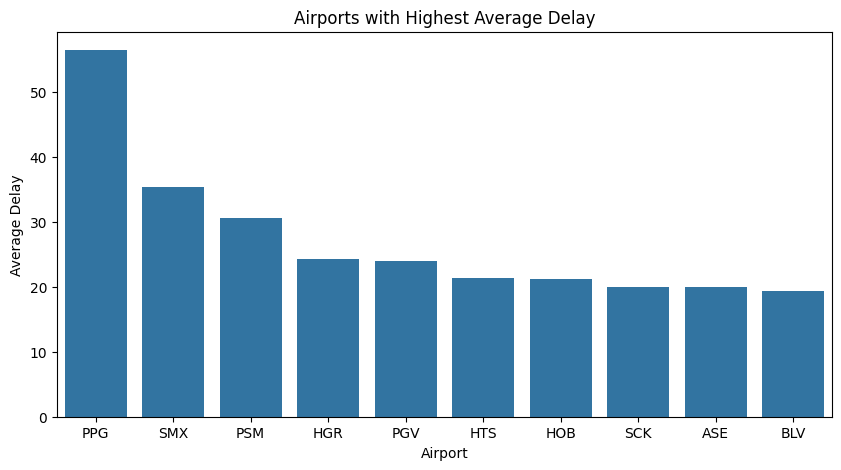

In [9]:
delay_airport = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=delay_airport.index, y=delay_airport.values)
plt.title("Airports with Highest Average Delay")
plt.xlabel("Airport")
plt.ylabel("Average Delay")
plt.show()

   **Insight:**
   * The chart shows the airports with the highest average arrival delays.
   * Airport PPG has the highest average delay among all airports.
   * Other airports like SMX, PSM, and HGR also show relatively high average delays.
   * High average delay at these airports may be due to weather conditions, low flight frequency, or operational inefficiencies.
   * Smaller airports sometimes show higher average delays because fewer flights can increase the average delay value.
   * Airlines should focus on improving scheduling and operations at these high-delay airports to reduce overall delays.

# Part 2: Seasonal and Cancellation Analysis

**6.. Monthly Cancellation Trend**


We analyze the number of cancellations per month.

Why We Are Doing This

This helps to:

*   Identify which months have the most cancellations
*   Understand seasonal impact on airline operations
*   Chart Used---
Line Chart: Monthly Cancellations

**Create MONTH Column**

In [14]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month
df['DAY'] = df['FL_DATE'].dt.day
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek

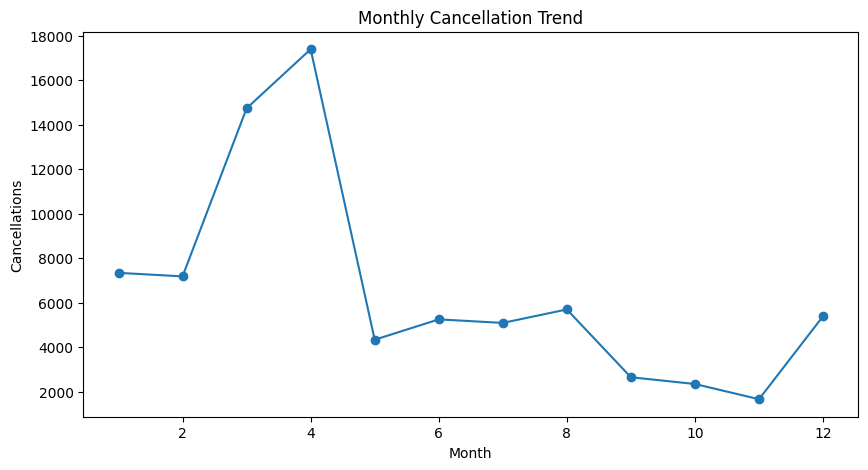

In [15]:
monthly_cancel = df.groupby('MONTH')['CANCELLED'].sum()

plt.figure(figsize=(10,5))
monthly_cancel.plot(marker='o')
plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancellations")
plt.show()

  **Insight:**
   * The line chart shows the number of flight cancellations for each month.
   * Cancellations are highest around months 3 and 4, indicating seasonal impact on flight operations.
   * After month 4, cancellations drop significantly, showing more stable flight operations in later months.
   * Some fluctuations are observed throughout the year, indicating that cancellations vary by season.
   * Higher cancellations may be due to weather conditions, technical issues, or operational problems.
   * This analysis helps airlines prepare better for high cancellation months and improve planning and scheduling.

**7. Cancellation by Reason**


We analyze different reasons for cancellations:

Carrier Delay

> Weather Delay, NAS Delay, Security Delay


Why We Are Doing This

This helps to:

*   Identify the main reason behind cancellations
*   Help airlines focus on major problem areas
*   Chart Used---
Bar Chart: Cancellation Reasons

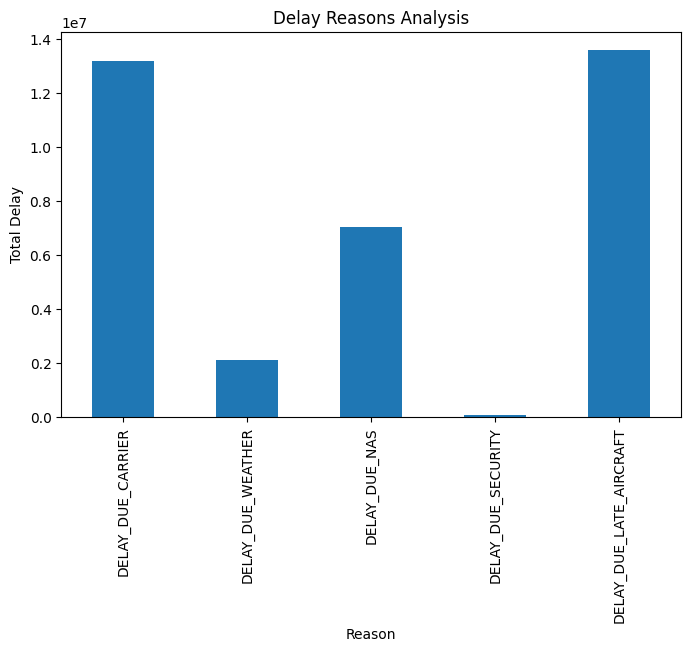

In [20]:
cancel_reason = df[['DELAY_DUE_CARRIER',
                    'DELAY_DUE_WEATHER',
                    'DELAY_DUE_NAS',
                    'DELAY_DUE_SECURITY',
                    'DELAY_DUE_LATE_AIRCRAFT']].sum()

plt.figure(figsize=(8,5))
cancel_reason.plot(kind='bar')
plt.title("Delay Reasons Analysis")
plt.xlabel("Reason")
plt.ylabel("Total Delay")
plt.show()

  **Insight:**
   * The bar chart shows the total delay caused by different factors.
   * Late aircraft delay and carrier delay are the two biggest causes of flight delays.
   * NAS delay (National Air System delay) is also a significant contributor to delays.
   * Weather delay contributes to delays but is lower compared to carrier and late aircraft delays.
   * Security delay is very minimal and has the least impact on total delays.
   * Airlines should focus on better aircraft scheduling and operational efficiency to reduce late aircraft and carrier delays.
   * Improving coordination with airport authorities can help reduce NAS-related delays.

**8. Seasonal Delay Trend**


We analyze the average delay for each month.

Why We Are Doing This

This helps to:

*   Understand seasonal delay patterns
*   Identify high delay months
*   Chart Used---
Line Chart: Average Delay by Month

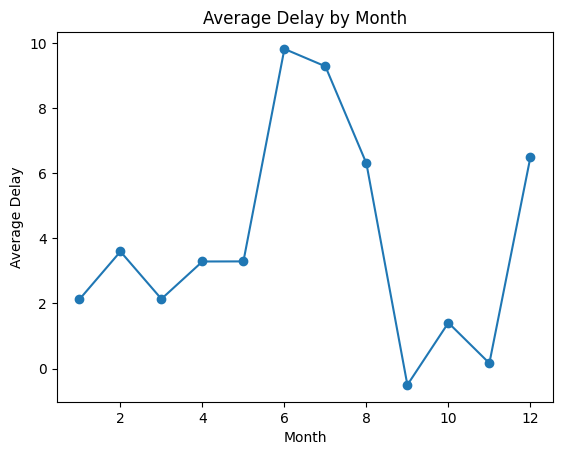

In [21]:
season_delay = df.groupby('MONTH')['ARR_DELAY'].mean()

season_delay.plot(kind='line', marker='o')
plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay")
plt.show()

   **Insight:**
   * The line chart shows the average flight delay for each month.
   * Average delays are higher in the middle months of the year, especially around months 6 and 7.
   * Delays decrease in some months and increase again toward the end of the year.
   * Seasonal factors such as weather conditions, holidays, and air traffic affect flight delays.
   * Months with high air traffic and bad weather tend to have higher average delays.
   * This analysis helps airlines prepare better for high delay months and improve scheduling and resource planning.

**9. Key Insights from Milestone 3**

*   The busiest routes were found between major airports, indicating high passenger demand and heavy air traffic.
*   Some airports showed consistently higher average delays, possibly due to congestion and weather conditions.
*   Route-level analysis revealed that high-traffic routes also experienced higher delays.
*   Monthly analysis showed that flight cancellations were higher during winter months.
*   Weather and carrier-related issues were the main reasons for cancellations.
*   Seasonal trends showed that delays increased during winter and holiday seasons.
*   These insights can help airlines improve scheduling, manage airport congestion, and reduce delays and cancellations.

**10. Deliverables for Milestone 3**



1. Top 10 Busiest Routes – Bar Chart



1. Top 10 Busiest Airports – Bar Chart
2. Average Delay by Airport – Heatmap
3. Routes with Highest Average Delay – Bar Chart
4. Monthly Cancellation Trend – Line Chart
5. Cancellation Reasons – Bar Chart
6. Average Delay by Month – Line Chart